## CS 598 PSL Fall 2026
### Coding Assignment 1

- Anirudh Eswara
- Ryan Lenea
- Mark Synowiec
- Robert Walker

The [Banknote Authentication Dataset](https://archive.ics.uci.edu/dataset/267/banknote+authentication) was used for this assignment.

This data set contains 1,372 samples of genuine and forged banknote-like specimens. Features
were extracted from images using a Wavelet Transform tool, resulting in 4 continuous
features:

1. variance of wavelet transformed image
2. skewness of wavelet transformed image
3. curtosis of wavelet transformed image
4. entropy of image

The response is a binary class label (0 = genuine, 1 = forged). There are no missing values.

In [2]:
# first install the ucimlrepo package:
#pip3 install ucimlrepo

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
banknote_authentication = fetch_ucirepo(id=267) 
  
# data (as pandas dataframes) 
X = banknote_authentication.data.features 
y = banknote_authentication.data.targets 
  
# metadata 
print(banknote_authentication.metadata) 
  
# variable information 
print(banknote_authentication.variables) 

{'uci_id': 267, 'name': 'Banknote Authentication', 'repository_url': 'https://archive.ics.uci.edu/dataset/267/banknote+authentication', 'data_url': 'https://archive.ics.uci.edu/static/public/267/data.csv', 'abstract': 'Data were extracted from images that were taken for the evaluation of an authentication procedure for banknotes.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1372, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C55P57', 'creators': ['Volker Lohweg'], 'intro_paper': None, 'additional_info': {'summary': 'Data were extracted from images that were taken from genuine and forged banknote-like specimens.  For digitization, an industrial camera usually used for print inspection was used. The final im

### Problem 1

Data preparation: Use a random 70% / 30% train–test split of the full data set. Set the random seed to 598 for reproducibility of the split.

Our goal is to compare the performance of a simple linear regression and a k-nearest neighbor classification approach on the data. Use a naive approach for the linear regression in which you treat the response as continuous and then convert the continuous predictions to a binary classifier by thresholding at 0.5. For the kNN approach, use k = 1 : 20.

(a) [35 points] Plot the two errors (misclassification rate on the test set) against the corresponding k values. Make sure that you annotate the plots (e.g., using different colors or types of line) and add legends as needed. Also report the test error of the naive linear regression classifier as a horizontal reference line on the same plot.

/Users/liamwalker/Desktop/UIUC/PSL/.venv/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/liamwalker/Desktop/UIUC/PSL/.venv/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/liamwalker/Desktop/UIUC/PSL/.venv/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/liamwalker/Desktop/UIUC/PSL/.venv/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversi

<function matplotlib.pyplot.show(close=None, block=None)>

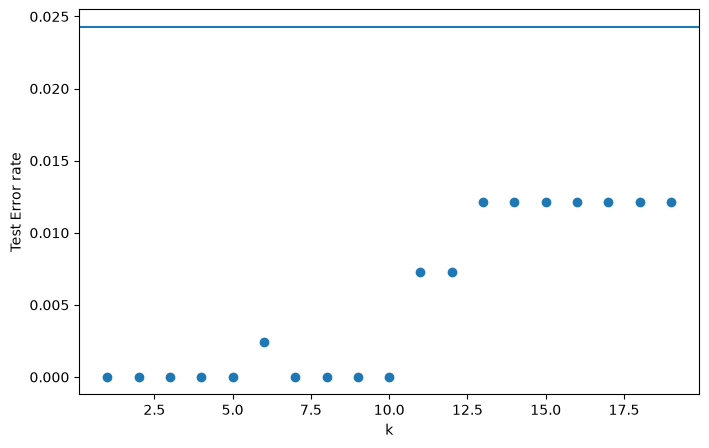

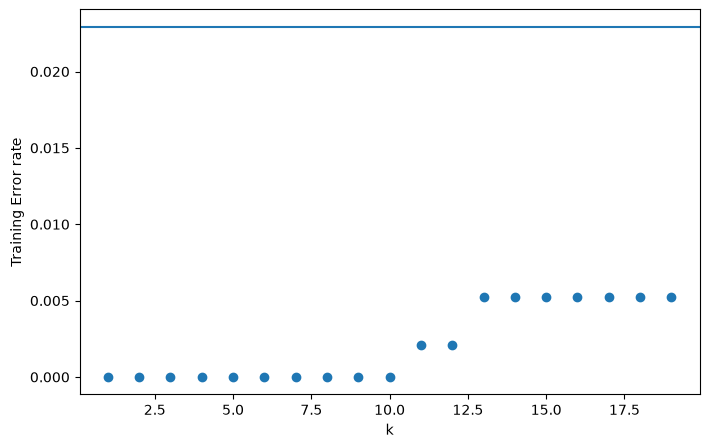

In [28]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import neighbors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=598, test_size=.3)

# Linear Regression
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)
# testing error
test_array = np.array(reg.predict(X_test))
y_pred_test = np.where(test_array > .5, 1, 0)
lin_reg_test_err = 1 - accuracy_score(y_test, y_pred_test)
# training error 
train_array = np.array(reg.predict(X_train))
y_pred_train = np.where(train_array > .5, 1, 0)
lin_reg_train_err = 1 - accuracy_score(y_train, y_pred_train)

# K-Nearest Neighbors
knn_test_errors = []
knn_train_errors = []
for n in range(1,20):
    knn = neighbors.KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    knn_y_pred_test = knn.predict(X_test)
    knn_y_pred_train = knn.predict(X_train)
    knn_test_err = 1 - accuracy_score(y_test, knn_y_pred_test)
    knn_train_err = 1 - accuracy_score(y_train, knn_y_pred_train)
    knn_test_errors.append(knn_test_err)
    knn_train_errors.append(knn_train_err)

# plot test error knn vs linear regression
ks = range(1,20)
plt.figure(figsize=(8,5))
plt.plot(ks, knn_test_errors, marker='o', linestyle='none',label='Test')
plt.axhline(lin_reg_test_err)
plt.xlabel('k')
plt.ylabel('Test Error rate')
plt.legend
plt.show

# plot training error knn vs linear regression
ks = range(1,20)
plt.figure(figsize=(8,5))
plt.plot(ks, knn_train_errors, marker='o', linestyle='none',label='Test')
plt.axhline(lin_reg_train_err)
plt.xlabel('k')
plt.ylabel('Training Error rate')
plt.legend
plt.show


(b) [15 points] Does the plot match (approximately) your intuition of the bias–variance tradeoff in terms of having a U-shaped error? What is the optimal k value based on this result? For the optimal k, what are the corresponding degrees-of-freedom and its error? Discuss.

TODO discuss questions above. - Ryan

### Problem 2

The goal in this problem is to write your very own kNN function!

(a) [5 points] Generate 3 independent standard Normal variables X1,X2,X3 of n = 1000 independent observations. Generate the response Y from the following nonlinear model:
Y = X1 + 2 · X2 − X3 + 0.5 · X1X2 + ε where the errors ε are IID N(0, 1). Set the random seed to 598 for reproducibility.

In [ ]:
import pandas as pd
import numpy as np
RANDOM_SEED = 598
n = 1000

rng = np.random.default_rng(RANDOM_SEED)

X1 = rng.standard_normal(n)
X2 = rng.standard_normal(n)
X3 = rng.standard_normal(n)
epsilon = rng.standard_normal(n)

#display(X1)
#display(X2)
#display(X3)
#display(epsilon)

Y = X1 + 2*X2 - X3 + 0.5 * X1 * X2 + epsilon


display(Y)

array([-8.98391839e-01,  6.58666386e+00, -9.86691160e-01, -1.76703973e+00,
       -1.37270479e+00, -3.22073981e+00,  1.12721989e+00,  6.14491020e-01,
       -3.25200128e+00, -3.53031723e+00, -1.37855445e+00,  4.76961741e+00,
        9.07730464e-01, -8.78952038e-01,  1.60325439e+00, -3.35430583e+00,
        1.06723990e+00, -3.66807247e+00, -1.70862480e+00, -4.86118527e+00,
       -2.38789611e+00, -2.83171195e+00, -1.48727830e+00, -4.94831112e-01,
       -3.02104239e+00, -3.17405954e-01, -1.91524342e+00,  1.06217056e+00,
       -2.54472858e-01,  3.04195839e+00, -2.82049768e+00,  1.67093131e+00,
       -1.77505589e+00,  6.75792130e+00,  4.19029954e-01,  1.57367994e+00,
        6.45172319e+00,  3.28443135e+00, -7.07282315e-01, -2.85126383e-01,
       -1.70068847e+00,  1.38145125e-01, -1.09262982e+00,  2.70001611e+00,
        3.16216069e+00,  6.39838701e-01,  5.99003217e-01,  1.72365226e+00,
        6.89107300e-01,  2.39969931e+00, -1.48846901e-01,  1.17611310e+00,
        1.17814641e+00, -

(b) [10 points] Use the appropriate built-in kNN function in R or Python (Euclidean distance) and report the mean squared error (MSE) on the test set for k = 1, 5, 10, 20. Use the first 500 observations as the training data and the remaining 500 as the testing data.

In [ ]:
#TODO - Liam

(c) [35 points] For this question, you cannot load any additional packages. Write your own kNN function mykNN(xtrain, ytrain, xtest, k) that fits a kNN model and predicts multiple target points xtest. The function should return ytest.

Notes:

- xtrain is the training data set feature matrix
- ytrain is the training data set response vector
- xtest is the testing data set feature matrix
- ytest is the testing data set vector of predictors

Test your implementation by computing the MSE on the testing data for the same values k = 1, 5, 10, 20. Your results should be very close to those obtained with the built-in function in part (b).

Recall that the MSE is defined as
$MSE = {\frac 1 n} \sum\limits_{i=1}^n (y_i − \hat{y}_i)^2$

In [ ]:
#TODO - Mark